# Comparatie modele ML — Employee Churn Prediction
---
Acest notebook **nu antreneaza niciun model**. Citeste direct din baza de date predictiile generate de cele 3 modele in notebook-urile individuale si le compara pe aceiasi angajati.

**Surse de date:**
- `predictii_churn_rf` — predictii generate de Random Forest
- `predictii_churn_lr` — predictii generate de Logistic Regression
- `predictii_churn_xgb` — predictii generate de XGBoost

> **De ce aceasta abordare?**  
> Compararea predictiilor salvate in baza de date garanteaza ca analizam exact ce a produs fiecare model in notebook-ul sau, fara nicio reantrenare sau variatie introdusa de o noua rulare. Aceasta este abordarea corecta intr-un proiect real, unde modelele sunt antrenate o singura data si predictiile lor sunt persistate.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import mysql.connector

print("Toate importurile au fost realizate cu succes!")

Toate importurile au fost realizate cu succes!


In [2]:
DB_CONFIG = {
    'host':     'localhost',
    'user':     'root',
    'password': '',
    'database': 'my_database',
    'port':     3306
}

try:
    conn = mysql.connector.connect(**DB_CONFIG)
    print("Conexiune la baza de date reusita!")
    conn.close()
except mysql.connector.Error as e:
    print(f"Eroare conexiune: {e}")

Conexiune la baza de date reusita!


## Extragerea predictiilor din baza de date

Facem JOIN intre cele 3 tabele de predictii pe `id_angajat`, astfel incat fiecare rand din dataframe-ul final reprezinta un angajat activ cu probabilitatile de churn estimate de fiecare model.

In [3]:
query = """
SELECT
    rf.id_angajat,

    -- probabilitati per model
    rf.probabilitate  AS prob_rf,
    lr.probabilitate  AS prob_lr,
    xgb.probabilitate AS prob_xgb,

    -- niveluri de risc per model
    rf.nivel_risc     AS risc_rf,
    lr.nivel_risc     AS risc_lr,
    xgb.nivel_risc    AS risc_xgb,

    -- date despre angajat pentru analiza contextuala
    a.salariu_curent,
    ROUND(DATEDIFF(CURDATE(), a.data_angajare) / 365, 2) AS vechime_ani,
    p.nivel           AS nivel_pozitie,
    d.nume            AS departament,
    d.locatie,
    mgr.tip           AS tip_manager

FROM predictii_churn_rf rf
JOIN predictii_churn_lr  lr  ON rf.id_angajat = lr.id_angajat
JOIN predictii_churn_xgb xgb ON rf.id_angajat = xgb.id_angajat
JOIN angajati a              ON rf.id_angajat = a.id_angajat
JOIN pozitii p               ON a.id_pozitie  = p.id_pozitie
JOIN departamente d          ON a.id_departament = d.id_departament
JOIN manageri mgr            ON a.id_manager = mgr.id_manager

ORDER BY rf.probabilitate DESC
"""

conn = mysql.connector.connect(**DB_CONFIG)
df = pd.read_sql(query, conn)
conn.close()

# conversie coloane numerice
for col in ['prob_rf', 'prob_lr', 'prob_xgb']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"✓ Date extrase cu succes!")
print(f"  Angajati activi analizati: {len(df)}")
print(f"  Coloane disponibile:       {list(df.columns)}")
df.head(10)

✓ Date extrase cu succes!
  Angajati activi analizati: 1795
  Coloane disponibile:       ['id_angajat', 'prob_rf', 'prob_lr', 'prob_xgb', 'risc_rf', 'risc_lr', 'risc_xgb', 'salariu_curent', 'vechime_ani', 'nivel_pozitie', 'departament', 'locatie', 'tip_manager']


,id_angajat,prob_rf,prob_lr,prob_xgb,risc_rf,risc_lr,risc_xgb,salariu_curent,vechime_ani,nivel_pozitie,departament,locatie,tip_manager
0,1675,0.8334,0.9221,0.8397,Mare,Mare,Mare,43914.54,4.82,consultant,Human Resources,Craiova,project_manager
1,415,0.8279,0.8947,0.8485,Mare,Mare,Mare,51120.92,2.65,consultant,Human Resources,Bucuresti,team_leader
2,176,0.8248,0.7754,0.4642,Mare,Mare,Mediu,29533.60,0.59,intermediate,Testing (Manual),Craiova,project_manager
3,581,0.7918,0.8191,0.1145,Mare,Mare,Mic,18970.74,6.45,intermediate,DevOps & Cloud,Sibiu,director
4,1764,0.7907,0.9402,0.1495,Mare,Mare,Mic,28313.78,4.97,senior,Human Resources,Iasi,director
5,811,0.7807,0.9280,0.9202,Mare,Mare,Mare,24850.79,3.19,intermediate,Testing (Manual),Iasi,director
6,611,0.7802,0.9314,0.8826,Mare,Mare,Mare,16914.84,7.00,associate,Testing (QA Automation),Iasi,project_manager
7,1876,0.7770,0.9567,0.2596,Mare,Mare,Mic,17905.26,1.70,intermediate,Data & AI Engineering,Sibiu,project_manager
8,890,0.7698,0.5688,0.7147,Mare,Mediu,Mare,28469.45,5.19,intermediate,DevOps & Cloud,Craiova,director
9,140,0.7486,0.9301,0.8626,Mare,Mare,Mare,13069.40,3.50,junior,Human Resources,Sibiu,director


In [4]:
print("=== Valori lipsa ===")
print(df[['prob_rf', 'prob_lr', 'prob_xgb', 'risc_rf', 'risc_lr', 'risc_xgb']].isnull().sum())
print(f"\n=== Statistici probabilitati ===")
print(df[['prob_rf', 'prob_lr', 'prob_xgb']].describe().round(4))

=== Valori lipsa ===
prob_rf     0
prob_lr     0
prob_xgb    0
risc_rf     0
risc_lr     0
risc_xgb    0
dtype: int64

=== Statistici probabilitati ===
         prob_rf    prob_lr   prob_xgb
count  1795.0000  1795.0000  1795.0000
mean      0.1671     0.3124     0.0366
std       0.1771     0.2731     0.0891
min       0.0000     0.0020     0.0001
25%       0.0300     0.0670     0.0017
50%       0.0785     0.2192     0.0077
75%       0.2747     0.4924     0.0348
max       0.8334     0.9619     0.9202


## Tabel comparativ — distributia nivelurilor de risc

Prima analiza: cati angajati incadreaza fiecare model in fiecare nivel de risc. Diferentele intre modele arata cat de **conservator sau agresiv** este fiecare algoritm in flagarea angajatilor cu risc.

In [5]:
ordine_risc = ['Mic', 'Mediu', 'Mare']

risc_rf  = df['risc_rf'].value_counts().reindex(ordine_risc)
risc_lr  = df['risc_lr'].value_counts().reindex(ordine_risc)
risc_xgb = df['risc_xgb'].value_counts().reindex(ordine_risc)

df_risc = pd.DataFrame({
    'Random Forest':       risc_rf.values,
    'Logistic Regression': risc_lr.values,
    'XGBoost':             risc_xgb.values
}, index=ordine_risc)

df_risc_pct = df_risc.div(df_risc.sum()) * 100

print("=== DISTRIBUTIA RISCULUI — NUMAR ANGAJATI ===")
print(df_risc.to_string())
print("\n=== DISTRIBUTIA RISCULUI — PROCENTE ===")
print(df_risc_pct.round(2).to_string())

=== DISTRIBUTIA RISCULUI — NUMAR ANGAJATI ===
       Random Forest  Logistic Regression  XGBoost
Mic             1386                 1017     1755
Mediu            361                  471       27
Mare              41                  307       13

=== DISTRIBUTIA RISCULUI — PROCENTE ===
       Random Forest  Logistic Regression  XGBoost
Mic            77.52                56.66    97.77
Mediu          20.19                26.24     1.50
Mare            2.29                17.10     0.72


## Vizualizare 1 — Distributia nivelurilor de risc comparativ

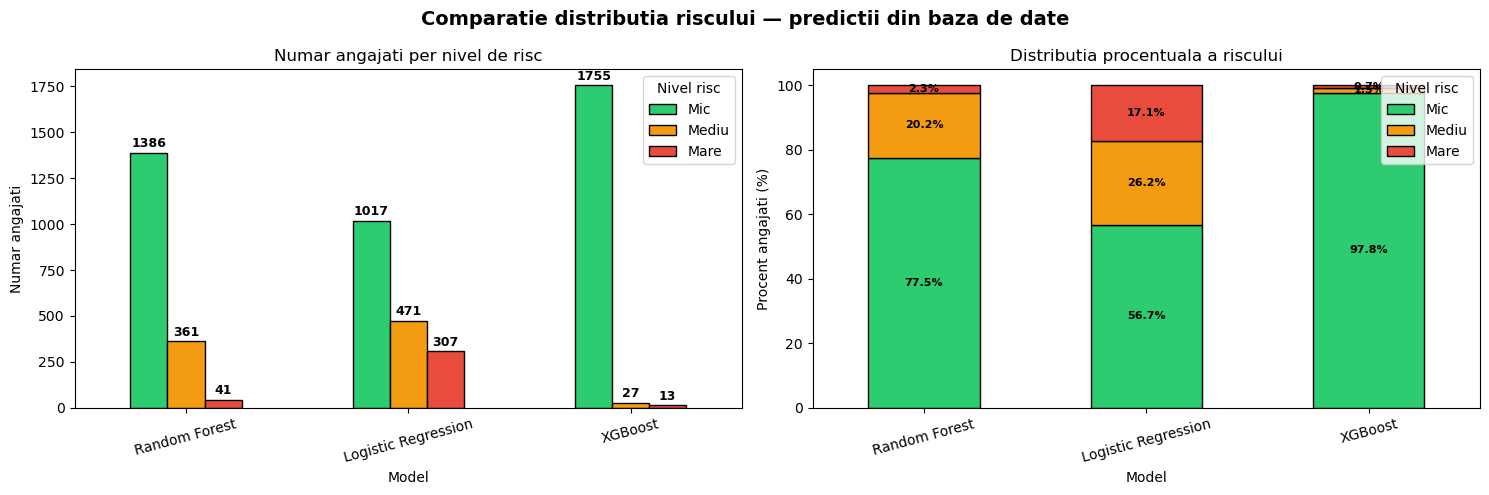

✓ Grafic salvat: cmp_distributie_risc.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Comparatie distributia riscului — predictii din baza de date',
             fontsize=14, fontweight='bold')

culori_risc = ['#2ecc71', '#f39c12', '#e74c3c']

# numar angajati
df_risc.T.plot(kind='bar', ax=axes[0],
               color=culori_risc, edgecolor='black')
axes[0].set_title('Numar angajati per nivel de risc')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Numar angajati')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Nivel risc')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', label_type='edge',
                      fontsize=9, fontweight='bold', padding=2)

# procente stacked
df_risc_pct.T.plot(kind='bar', stacked=True, ax=axes[1],
                   color=culori_risc, edgecolor='black')
axes[1].set_title('Distributia procentuala a riscului')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Procent angajati (%)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Nivel risc', loc='upper right')
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', label_type='center',
                      fontsize=8, fontweight='bold', color='black')

plt.tight_layout()
plt.savefig('cmp_distributie_risc.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Grafic salvat: cmp_distributie_risc.png")

## Vizualizare 2 — Distributia probabilitatilor (histograme)

Histogramele arata modul in care fiecare model **distribuie scorurile de risc** pe intreaga populatie de angajati activi. Un model bine calibrat separa clar angajatii cu risc mic (probabilitati aproape de 0) de cei cu risc mare (aproape de 1). Concentrarea in zona 0.4-0.6 indica incertitudine ridicata a modelului.

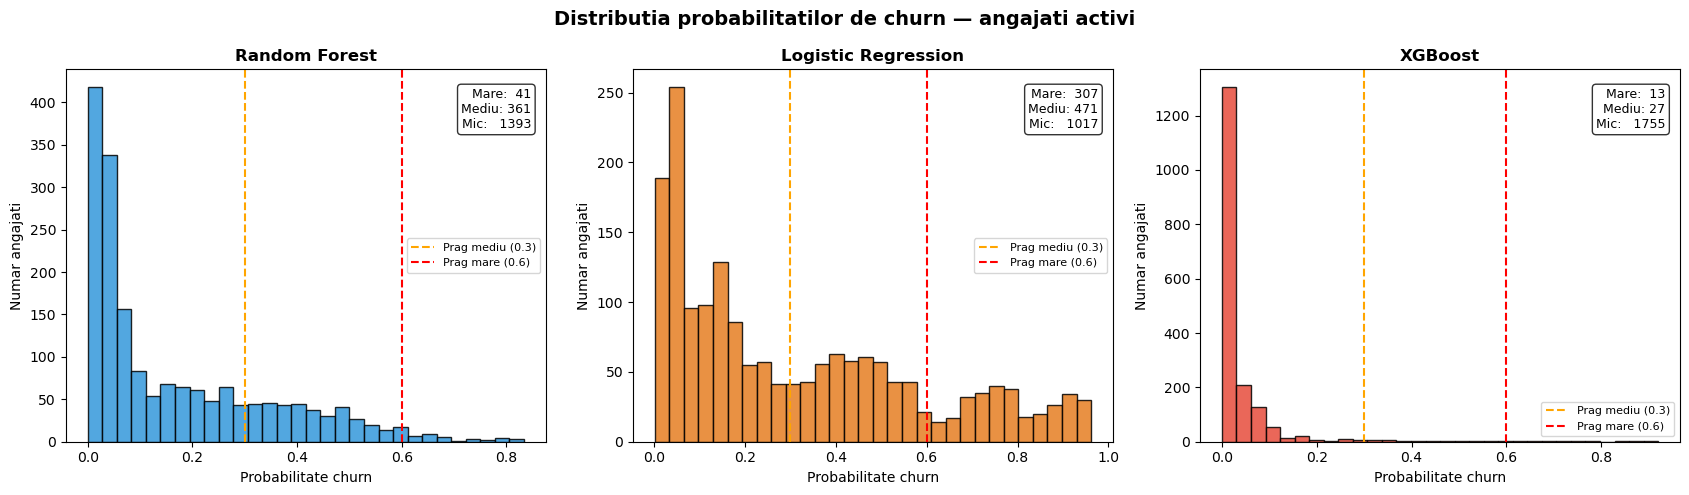

✓ Grafic salvat: cmp_distributie_prob.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Distributia probabilitatilor de churn — angajati activi',
             fontsize=14, fontweight='bold')

modele_hist = [
    ('prob_rf',  'Random Forest',       '#3498db'),
    ('prob_lr',  'Logistic Regression', '#e67e22'),
    ('prob_xgb', 'XGBoost',             '#e74c3c'),
]

for ax, (col, nume, culoare) in zip(axes, modele_hist):
    probs = df[col].dropna()
    ax.hist(probs, bins=30, color=culoare, edgecolor='black', alpha=0.85)
    ax.axvline(x=0.3, color='orange', linestyle='--', lw=1.5, label='Prag mediu (0.3)')
    ax.axvline(x=0.6, color='red',    linestyle='--', lw=1.5, label='Prag mare (0.6)')
    ax.set_title(nume, fontweight='bold')
    ax.set_xlabel('Probabilitate churn')
    ax.set_ylabel('Numar angajati')
    ax.legend(fontsize=8)

    risc_mare  = (probs >= 0.6).sum()
    risc_mediu = ((probs >= 0.3) & (probs < 0.6)).sum()
    risc_mic   = (probs < 0.3).sum()
    ax.text(0.97, 0.95,
            f'Mare:  {risc_mare}\nMediu: {risc_mediu}\nMic:   {risc_mic}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('cmp_distributie_prob.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Grafic salvat: cmp_distributie_prob.png")

## Vizualizare 3 — Corelatie intre probabilitatile modelelor

Scatter plot-urile arata cat de mult **sunt de acord** cele 3 modele in privinta fiecarui angajat. Daca punctele sunt concentrate pe diagonala, modelele concorda. Punctele departe de diagonala reprezinta angajati pe care modelele ii evalueaza diferit — acestia merita atentie speciala.

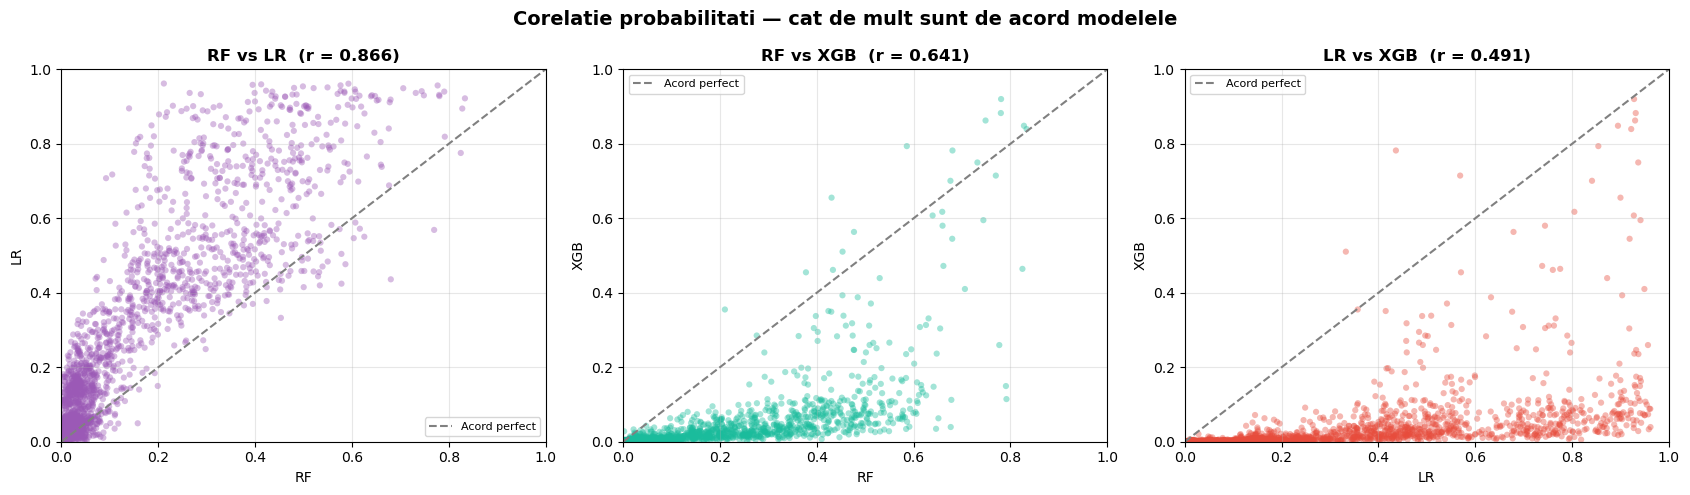

✓ Grafic salvat: cmp_corelatie_prob.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Corelatie probabilitati — cat de mult sunt de acord modelele',
             fontsize=14, fontweight='bold')

perechi = [
    ('prob_rf',  'prob_lr',  'RF vs LR',  '#9b59b6'),
    ('prob_rf',  'prob_xgb', 'RF vs XGB', '#1abc9c'),
    ('prob_lr',  'prob_xgb', 'LR vs XGB', '#e74c3c'),
]

for ax, (col_x, col_y, titlu, culoare) in zip(axes, perechi):
    ax.scatter(df[col_x], df[col_y],
               alpha=0.4, s=20, color=culoare, edgecolor='none')
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5,
            label='Acord perfect')

    corel = df[[col_x, col_y]].corr().iloc[0, 1]
    ax.set_title(f'{titlu}  (r = {corel:.3f})', fontweight='bold')
    ax.set_xlabel(col_x.replace('prob_', '').upper())
    ax.set_ylabel(col_y.replace('prob_', '').upper())
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cmp_corelatie_prob.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Grafic salvat: cmp_corelatie_prob.png")

## Vizualizare 4 — Probabilitate medie per departament

Comparam riscul mediu estimat de fiecare model per departament. Daca toate cele 3 modele identifica acelasi departament ca avand cel mai mare risc, concluzia este robusta si poate fi prezentata cu incredere echipei HR.

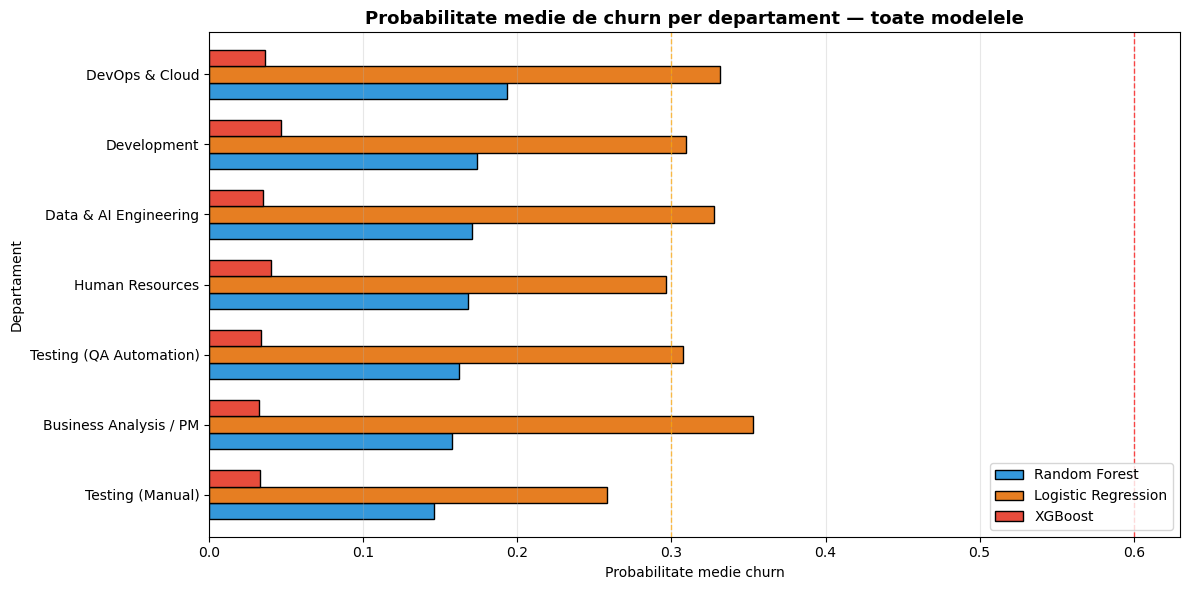

=== DEPARTAMENT CU RISC MAXIM PER MODEL ===
  RF: DevOps & Cloud (0.1934)
  LR: Business Analysis / PM (0.3528)
  XGB: Development (0.0466)

✓ Grafic salvat: cmp_risc_departament.png


In [9]:
risc_dept = df.groupby('departament')[['prob_rf', 'prob_lr', 'prob_xgb']].mean()
risc_dept.columns = ['Random Forest', 'Logistic Regression', 'XGBoost']
risc_dept = risc_dept.sort_values('Random Forest', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
risc_dept.plot(kind='barh', ax=ax,
               color=['#3498db', '#e67e22', '#e74c3c'],
               edgecolor='black', width=0.7)
ax.set_title('Probabilitate medie de churn per departament — toate modelele',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Probabilitate medie churn')
ax.set_ylabel('Departament')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
ax.axvline(x=0.3, color='orange', linestyle='--', lw=1, alpha=0.7)
ax.axvline(x=0.6, color='red',    linestyle='--', lw=1, alpha=0.7)

plt.tight_layout()
plt.savefig('cmp_risc_departament.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== DEPARTAMENT CU RISC MAXIM PER MODEL ===")
for col, nume in [('Random Forest', 'RF'), ('Logistic Regression', 'LR'), ('XGBoost', 'XGB')]:
    dept_max = risc_dept[col].idxmax()
    val_max  = risc_dept.loc[dept_max, col]
    print(f"  {nume}: {dept_max} ({val_max:.4f})")

print("\n✓ Grafic salvat: cmp_risc_departament.png")

## Vizualizare 5 — Probabilitate medie per nivel de pozitie

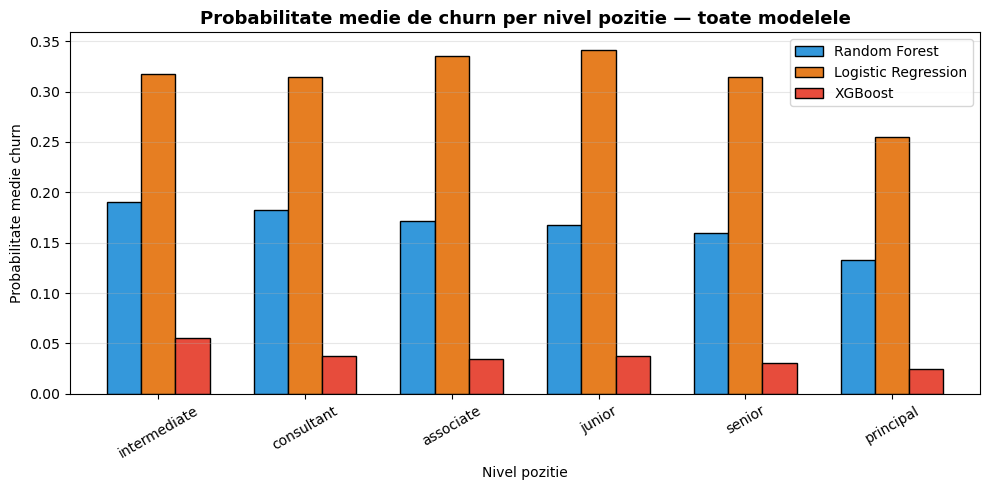

=== NIVEL POZITIE CU RISC MAXIM PER MODEL ===
  RF: intermediate (0.1904)
  LR: junior (0.3417)
  XGB: intermediate (0.0558)

✓ Grafic salvat: cmp_risc_nivel.png


In [10]:
risc_nivel = df.groupby('nivel_pozitie')[['prob_rf', 'prob_lr', 'prob_xgb']].mean()
risc_nivel.columns = ['Random Forest', 'Logistic Regression', 'XGBoost']
risc_nivel = risc_nivel.sort_values('Random Forest', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
risc_nivel.plot(kind='bar', ax=ax,
                color=['#3498db', '#e67e22', '#e74c3c'],
                edgecolor='black', width=0.7)
ax.set_title('Probabilitate medie de churn per nivel pozitie — toate modelele',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Nivel pozitie')
ax.set_ylabel('Probabilitate medie churn')
ax.tick_params(axis='x', rotation=30)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cmp_risc_nivel.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== NIVEL POZITIE CU RISC MAXIM PER MODEL ===")
for col, nume in [('Random Forest', 'RF'), ('Logistic Regression', 'LR'), ('XGBoost', 'XGB')]:
    nivel_max = risc_nivel[col].idxmax()
    val_max   = risc_nivel.loc[nivel_max, col]
    print(f"  {nume}: {nivel_max} ({val_max:.4f})")

print("\n✓ Grafic salvat: cmp_risc_nivel.png")

## Analiza dezacordurilor dintre modele

Cel mai valoros insight din comparatia directa a predictiilor: angajatii pe care modelele **nu sunt de acord**. Un angajat cu risc Mare dupa XGBoost dar Mic dupa Logistic Regression este un caz ambiguu care merita atentie manuala din partea HR.

In [12]:
# angajati pe care toate 3 modelele concorda ca risc MARE
consens_mare = df[
    (df['risc_rf'] == 'Mare') &
    (df['risc_lr'] == 'Mare') &
    (df['risc_xgb'] == 'Mare')
].copy()

# angajati pe care cel putin un model zice MARE dar nu toate
dezacord_mare = df[
    ((df['risc_rf'] == 'Mare') | (df['risc_lr'] == 'Mare') | (df['risc_xgb'] == 'Mare')) &
    ~((df['risc_rf'] == 'Mare') & (df['risc_lr'] == 'Mare') & (df['risc_xgb'] == 'Mare'))
].copy()

# angajati pe care toate 3 modelele concorda ca risc MIC
consens_mic = df[
    (df['risc_rf'] == 'Mic') &
    (df['risc_lr'] == 'Mic') &
    (df['risc_xgb'] == 'Mic')
].copy()

print("=== ANALIZA CONSENS / DEZACORD INTRE MODELE ===")
print(f"\nConsens RISC MARE (toate 3 modele de acord):  {len(consens_mare)} angajati")
print(f"Dezacord (cel putin un model zice MARE):      {len(dezacord_mare)} angajati")
print(f"Consens RISC MIC  (toate 3 modele de acord):  {len(consens_mic)} angajati")

if len(consens_mare) > 0:
    print(f"\n=== TOP 10 ANGAJATI CU RISC MARE CONFIRMAT DE TOATE 3 MODELELE ===")
    print(consens_mare.nlargest(10, 'prob_rf')[
        ['id_angajat', 'prob_rf', 'prob_lr', 'prob_xgb',
         'departament', 'nivel_pozitie', 'vechime_ani', 'salariu_curent']
    ].to_string(index=False))

=== ANALIZA CONSENS / DEZACORD INTRE MODELE ===

Consens RISC MARE (toate 3 modele de acord):  9 angajati
Dezacord (cel putin un model zice MARE):      304 angajati
Consens RISC MIC  (toate 3 modele de acord):  1010 angajati

=== TOP 10 ANGAJATI CU RISC MARE CONFIRMAT DE TOATE 3 MODELELE ===
 id_angajat  prob_rf  prob_lr  prob_xgb             departament nivel_pozitie  vechime_ani  salariu_curent
       1675   0.8334   0.9221    0.8397         Human Resources    consultant         4.82        43914.54
        415   0.8279   0.8947    0.8485         Human Resources    consultant         2.65        51120.92
        811   0.7807   0.9280    0.9202        Testing (Manual)  intermediate         3.19        24850.79
        611   0.7802   0.9314    0.8826 Testing (QA Automation)     associate         7.00        16914.84
        140   0.7486   0.9301    0.8626         Human Resources        junior         3.50        13069.40
       1993   0.7318   0.9366    0.7499             Development  

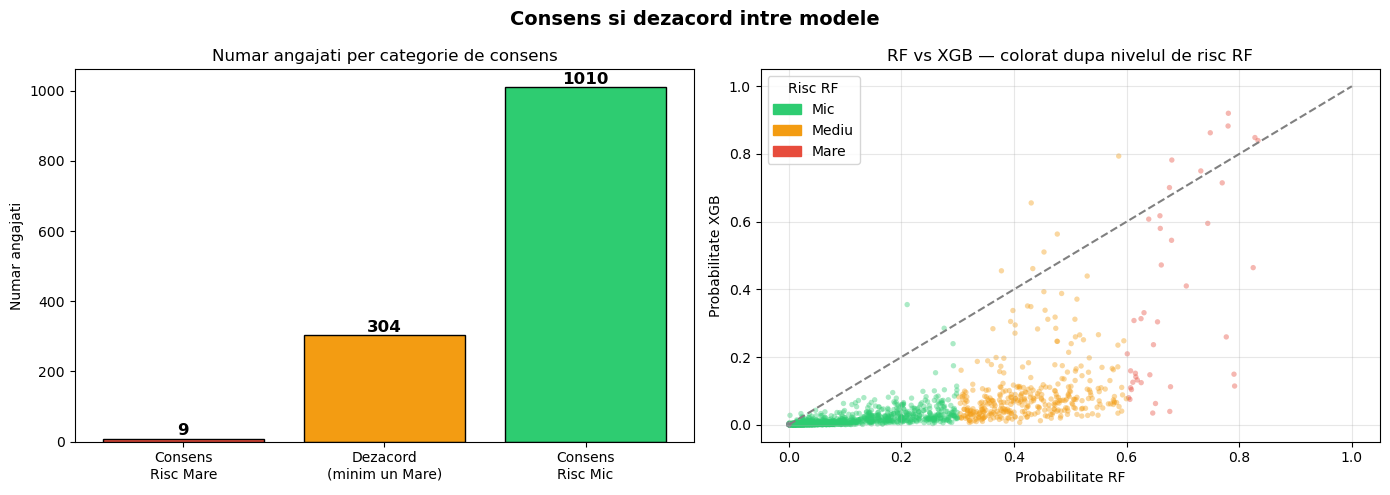

Grafic salvat: cmp_consens_dezacord.png


In [14]:
# vizualizare consens vs dezacord
categorii = [
    'Consens\nRisc Mare',
    'Dezacord\n(minim un Mare)',
    'Consens\nRisc Mic'
]
valori  = [len(consens_mare), len(dezacord_mare), len(consens_mic)]
culori  = ['#e74c3c', '#f39c12', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Consens si dezacord intre modele', fontsize=14, fontweight='bold')

# bar chart consens
bars = axes[0].bar(categorii, valori, color=culori, edgecolor='black')
axes[0].set_title('Numar angajati per categorie de consens')
axes[0].set_ylabel('Numar angajati')
for bar, val in zip(bars, valori):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom',
                 fontweight='bold', fontsize=12)

# scatter dezacord: RF vs XGB, colorat dupa risc RF
culori_risc_map = {'Mic': '#2ecc71', 'Mediu': '#f39c12', 'Mare': '#e74c3c'}
culori_scatter  = df['risc_rf'].map(culori_risc_map).fillna('#7f8c8d')
axes[1].scatter(df['prob_rf'], df['prob_xgb'],
                c=culori_scatter, alpha=0.4, s=15, edgecolor='none')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5)
axes[1].set_title('RF vs XGB — colorat dupa nivelul de risc RF')
axes[1].set_xlabel('Probabilitate RF')
axes[1].set_ylabel('Probabilitate XGB')
axes[1].grid(alpha=0.3)

legenda = [mpatches.Patch(color=v, label=k)
           for k, v in culori_risc_map.items()]
axes[1].legend(handles=legenda, title='Risc RF', loc='upper left')

plt.tight_layout()
plt.savefig('cmp_consens_dezacord.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafic salvat: cmp_consens_dezacord.png")

## Vizualizare 6 — Heatmap probabilitate medie per departament si model

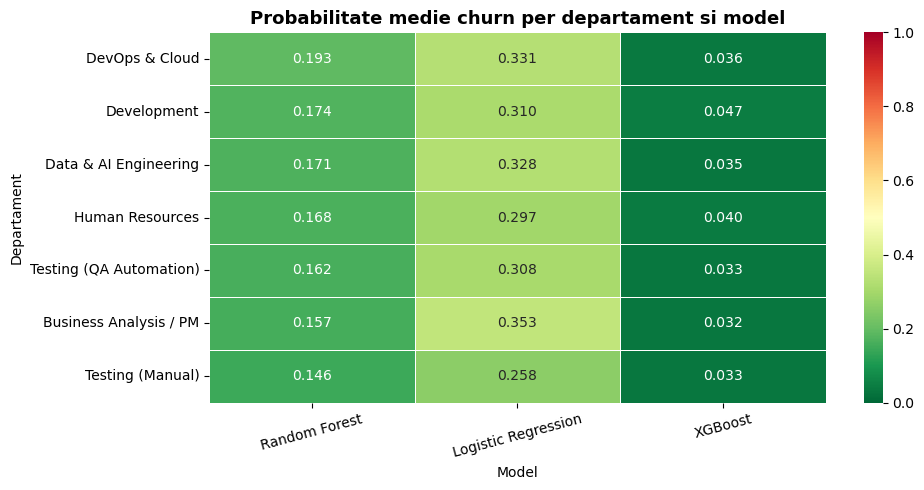

✓ Grafic salvat: cmp_heatmap_departament.png


In [15]:
heatmap_data = df.groupby('departament')[['prob_rf', 'prob_lr', 'prob_xgb']].mean()
heatmap_data.columns = ['Random Forest', 'Logistic Regression', 'XGBoost']
heatmap_data = heatmap_data.sort_values('Random Forest', ascending=False)

fig, ax = plt.subplots(figsize=(10, max(5, len(heatmap_data) * 0.55)))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.3f',
    cmap='RdYlGn_r',
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 10}
)
ax.set_title('Probabilitate medie churn per departament si model',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Departament')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('cmp_heatmap_departament.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Grafic salvat: cmp_heatmap_departament.png")

## Raport final de comparatie

In [16]:
print("=" * 60)
print("        RAPORT FINAL — COMPARATIE PREDICTII")
print("=" * 60)

print(f"\nAngajati activi analizati: {len(df)}")

print("\n--- DISTRIBUTIA RISCULUI ---")
print(f"{'Nivel':<8} {'RF':>8} {'LR':>8} {'XGB':>8}")
for nivel in ordine_risc:
    print(f"{nivel:<8}"
          f" {df_risc.loc[nivel, 'Random Forest']:>8}"
          f" {df_risc.loc[nivel, 'Logistic Regression']:>8}"
          f" {df_risc.loc[nivel, 'XGBoost']:>8}")

print("\n--- PROBABILITATE MEDIE GLOBALA ---")
for col, nume in [('prob_rf','RF'), ('prob_lr','LR'), ('prob_xgb','XGB')]:
    print(f"  {nume}: {df[col].mean():.4f}")

print("\n--- CONSENS INTRE MODELE ---")
print(f"  Angajati risc MARE confirmat de toate 3: {len(consens_mare)}")
print(f"  Angajati in dezacord (minim un Mare):    {len(dezacord_mare)}")
print(f"  Angajati risc MIC confirmat de toate 3:  {len(consens_mic)}")

print("\n--- DEPARTAMENT CU RISC MAXIM ---")
for col, nume in [('Random Forest','RF'), ('Logistic Regression','LR'), ('XGBoost','XGB')]:
    dept = risc_dept[col].idxmax()
    val  = risc_dept.loc[dept, col]
    print(f"  {nume}: {dept} ({val:.4f})")

print("\n--- FISIERE GENERATE ---")
for f in [
    'cmp_distributie_risc.png',
    'cmp_distributie_prob.png',
    'cmp_corelatie_prob.png',
    'cmp_risc_departament.png',
    'cmp_risc_nivel.png',
    'cmp_consens_dezacord.png',
    'cmp_heatmap_departament.png'
]:
    print(f"  - {f}")

print("\n" + "=" * 60)

        RAPORT FINAL — COMPARATIE PREDICTII

Angajati activi analizati: 1795

--- DISTRIBUTIA RISCULUI ---
Nivel          RF       LR      XGB
Mic          1386     1017     1755
Mediu         361      471       27
Mare           41      307       13

--- PROBABILITATE MEDIE GLOBALA ---
  RF: 0.1671
  LR: 0.3124
  XGB: 0.0366

--- CONSENS INTRE MODELE ---
  Angajati risc MARE confirmat de toate 3: 9
  Angajati in dezacord (minim un Mare):    304
  Angajati risc MIC confirmat de toate 3:  1010

--- DEPARTAMENT CU RISC MAXIM ---
  RF: DevOps & Cloud (0.1934)
  LR: Business Analysis / PM (0.3528)
  XGB: Development (0.0466)

--- FISIERE GENERATE ---
  - cmp_distributie_risc.png
  - cmp_distributie_prob.png
  - cmp_corelatie_prob.png
  - cmp_risc_departament.png
  - cmp_risc_nivel.png
  - cmp_consens_dezacord.png
  - cmp_heatmap_departament.png



## Concluzii finale

### Ce am comparat
Spre deosebire de o comparatie clasica bazata pe metrici de test (AUC, F1 etc.), aceasta analiza compara **predictiile reale** ale celor 3 modele pe aceiasi angajati activi, asa cum au fost salvate in baza de date.

### Interpretarea consensului
Angajatii identificati cu risc Mare de **toate cele 3 modele** reprezinta cazurile cu cea mai mare prioritate pentru departamentul HR — probabilitatea ca un astfel de angajat sa plece este ridicata indiferent de algoritmul folosit. Aceasta robustete a predictiei depaseste ca valoare orice metrica individuala de performanta.

Angajatii aflati in **zona de dezacord** (un model spune Mare, altul spune Mic) merita o analiza manuala — fie sunt cazuri cu profil atipic, fie unul dintre modele este mai bine calibrat pentru acel tip de angajat.

### Recomandare pentru departamentul HR
- **Prioritate maxima:** angajatii din `consens_mare` — actiune imediata
- **Monitorizare:** angajatii din `dezacord_mare` — evaluare individuala
- **Departamentele cu risc ridicat confirmat de toate modelele** necesita o strategie de retentie la nivel de echipa, nu doar individual

### Limitari
- Aceasta comparatie nu include metrici de performanta (AUC, F1 etc.) deoarece acestea necesita date reale etichetate de test — ele sunt disponibile in notebook-urile individuale ale fiecarui model
- Comparatia este valabila la momentul rularii notebook-urilor individuale; dupa reantrenare, tabelele din DB trebuie actualizate

## Comparatie Finalizata

**Fisiere generate:**
- `cmp_distributie_risc.png` — distributia nivelurilor de risc per model
- `cmp_distributie_prob.png` — histogramele probabilitatilor
- `cmp_corelatie_prob.png` — corelatie intre probabilitatile modelelor
- `cmp_risc_departament.png` — risc mediu per departament
- `cmp_risc_nivel.png` — risc mediu per nivel de pozitie
- `cmp_consens_dezacord.png` — analiza consens vs dezacord
- `cmp_heatmap_departament.png` — heatmap departament x model

**Surse de date folosite:**
- Tabela `predictii_churn_rf`
- Tabela `predictii_churn_lr`
- Tabela `predictii_churn_xgb`

**Tehnologii folosite:**
- Python, Pandas, NumPy
- MySQL Connector, Matplotlib, Seaborn
- MariaDB, phpMyAdmin